https://www.kaggle.com/code/modeh7/final-solution-ncaa-2025/notebook#%3C%3C--Hardest-difficulty-features--%3E%3E

https://www.kaggle.com/competitions/march-machine-learning-mania-2025/writeups/aziel888-5th-place-solution

https://github.com/fakyras/ncaa_women_2018/blob/master/win_ncaa.R

In [1]:
from google.colab import drive
drive.mount('/content/drive')

!mkdir -p ~/.kaggle
!cp /content/drive/MyDrive/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle competitions download -c march-machine-learning-mania-2026
!unzip /content/march-machine-learning-mania-2026.zip
!rm /content/march-machine-learning-mania-2026.zip

Mounted at /content/drive
  0% 0.00/34.3M [00:00<?, ?B/s]
100% 34.3M/34.3M [00:00<00:00, 1.04GB/s]
Archive:  /content/march-machine-learning-mania-2026.zip
  inflating: Cities.csv              
  inflating: Conferences.csv         
  inflating: MConferenceTourneyGames.csv  
  inflating: MGameCities.csv         
  inflating: MMasseyOrdinals.csv     
  inflating: MNCAATourneyCompactResults.csv  
  inflating: MNCAATourneyDetailedResults.csv  
  inflating: MNCAATourneySeedRoundSlots.csv  
  inflating: MNCAATourneySeeds.csv   
  inflating: MNCAATourneySlots.csv   
  inflating: MRegularSeasonCompactResults.csv  
  inflating: MRegularSeasonDetailedResults.csv  
  inflating: MSeasons.csv            
  inflating: MSecondaryTourneyCompactResults.csv  
  inflating: MSecondaryTourneyTeams.csv  
  inflating: MTeamCoaches.csv        
  inflating: MTeamConferences.csv    
  inflating: MTeamSpellings.csv      
  inflating: MTeams.csv              
  inflating: SampleSubmissionStage1.csv  
  inflating:

In [2]:
%%capture
# !pip install autogluon.tabular[all]
!pip install optuna

## Import Packages

In [3]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, GammaRegressor, Ridge
from sklearn.metrics import make_scorer, mean_squared_error, roc_auc_score
from sklearn.model_selection import GridSearchCV, cross_val_score, StratifiedKFold
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import chi2
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.ensemble import HistGradientBoostingClassifier


import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
# from keras_tuner import HyperModel
# from keras_tuner import RandomSearch
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from tensorflow.keras import layers, models

from sklearn.feature_selection import f_classif
from sklearn.metrics import brier_score_loss
from tqdm import tqdm

# from autogluon.tabular import TabularDataset, TabularPredictor

## Load Data

In [4]:
DATA_PATH = ""

# Regular season compact
m_reg = pd.read_csv(DATA_PATH + "MRegularSeasonCompactResults.csv")
w_reg = pd.read_csv(DATA_PATH + "WRegularSeasonCompactResults.csv")

# Tournament compact
m_tour = pd.read_csv(DATA_PATH + "MNCAATourneyCompactResults.csv")
w_tour = pd.read_csv(DATA_PATH + "WNCAATourneyCompactResults.csv")

# Seeds
m_seeds = pd.read_csv(DATA_PATH + "MNCAATourneySeeds.csv")
w_seeds = pd.read_csv(DATA_PATH + "WNCAATourneySeeds.csv")

print("Men Regular:", m_reg.shape)
print("Women Regular:", w_reg.shape)
print("Men Tour:", m_tour.shape)
print("Women Tour:", w_tour.shape)

Men Regular: (196823, 8)
Women Regular: (140825, 8)
Men Tour: (2585, 8)
Women Tour: (1717, 8)


In [49]:
m_reg

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,Gender
0,1985,20,1228,81,1328,64,N,0,1
1,1985,25,1106,77,1354,70,H,0,1
2,1985,25,1112,63,1223,56,H,0,1
3,1985,25,1165,70,1432,54,H,0,1
4,1985,25,1192,86,1447,74,H,0,1
...,...,...,...,...,...,...,...,...,...
196818,2026,93,1457,80,1347,78,A,0,1
196819,2026,93,1459,81,1440,67,A,0,1
196820,2026,93,1464,90,1236,61,A,0,1
196821,2026,93,1472,77,1355,62,A,0,1


In [5]:
# Combine men and women
m_reg["Gender"] = 1
w_reg["Gender"] = 0
m_tour["Gender"] = 1
w_tour["Gender"] = 0

m_seeds["Gender"] = 1
w_seeds["Gender"] = 0

reg = pd.concat([m_reg, w_reg], ignore_index=True)
tour = pd.concat([m_tour, w_tour], ignore_index=True)
seeds = pd.concat([m_seeds, w_seeds], ignore_index=True)

print("Combined Regular:", reg.shape)
print("Combined Tour:", tour.shape)

Combined Regular: (337648, 9)
Combined Tour: (4302, 9)


In [6]:
reg["Margin"] = reg["WScore"] - reg["LScore"]

# Winning rows
win_df = reg[[
    "Season","DayNum","WTeamID","WScore",
    "LTeamID","LScore","WLoc","Gender"
]].copy()

win_df.columns = [
    "Season","DayNum","TeamID","TeamScore",
    "OppID","OppScore","Loc","Gender"
]

win_df["Win"] = 1

# Losing rows
loss_df = reg[[
    "Season","DayNum","LTeamID","LScore",
    "WTeamID","WScore","WLoc","Gender"
]].copy()

loss_df.columns = [
    "Season","DayNum","TeamID","TeamScore",
    "OppID","OppScore","Loc","Gender"
]

loss_df["Win"] = 0

# Flip location
loss_df["Loc"] = loss_df["Loc"].map({"H":"A","A":"H","N":"N"})

team_games = pd.concat([win_df, loss_df], ignore_index=True)

team_games["Margin"] = team_games["TeamScore"] - team_games["OppScore"]

team_games.head()

,Season,DayNum,TeamID,TeamScore,OppID,OppScore,Loc,Gender,Win,Margin
0,1985,20,1228,81,1328,64,N,1,1,17
1,1985,25,1106,77,1354,70,H,1,1,7
2,1985,25,1112,63,1223,56,H,1,1,7
3,1985,25,1165,70,1432,54,H,1,1,16
4,1985,25,1192,86,1447,74,H,1,1,12


In [7]:
# Season Level Stats
season_stats = (
    team_games
    .groupby(["Season","TeamID","Gender"])
    .agg(
        games=("Win","count"),
        win_pct=("Win","mean"),
        avg_score=("TeamScore","mean"),
        avg_allowed=("OppScore","mean"),
        avg_margin=("Margin","mean")
    )
    .reset_index()
)

season_stats.head()

,Season,TeamID,Gender,games,win_pct,avg_score,avg_allowed,avg_margin
0,1985,1102,1,24,0.208333,63.083333,68.875000,-5.791667
1,1985,1103,1,23,0.391304,61.043478,64.086957,-3.043478
2,1985,1104,1,30,0.700000,68.500000,60.700000,7.800000
3,1985,1106,1,24,0.416667,71.625000,75.416667,-3.791667
4,1985,1108,1,25,0.760000,83.000000,75.040000,7.960000


In [8]:
# Add Seed Numbers
seeds["SeedNum"] = seeds["Seed"].str[1:3].astype(int)

seeds.head()

,Season,Seed,TeamID,Gender,SeedNum
0,1985,W01,1207,1,1
1,1985,W02,1210,1,2
2,1985,W03,1228,1,3
3,1985,W04,1260,1,4
4,1985,W05,1374,1,5


In [19]:
season_stats = season_stats.merge(
    seeds,
    on=["Season","TeamID","Gender"],
    how="left"
)

season_stats.head()

In [29]:
df = tour.copy()

df["Team1"] = df[["WTeamID","LTeamID"]].min(axis=1)
df["Team2"] = df[["WTeamID","LTeamID"]].max(axis=1)

df["Target"] = (df["WTeamID"] == df["Team1"]).astype(int)

df = df[["Season","Gender","Team1","Team2","Target"]]

In [30]:
# Create copies with prefixed columns
t1_stats = season_stats.copy()
t2_stats = season_stats.copy()

# Rename only feature columns
feature_cols = ["games","win_pct","avg_score","avg_allowed","avg_margin", "SeedNum"]

t1_stats = t1_stats.rename(
    columns={col: f"T1_{col}" for col in feature_cols}
)

t2_stats = t2_stats.rename(
    columns={col: f"T2_{col}" for col in feature_cols}
)


df = df.merge(
    t1_stats,
    left_on=["Season","Team1","Gender"],
    right_on=["Season","TeamID","Gender"],
    how="left"
)

df = df.drop(columns=["TeamID"])

df = df.merge(
    t2_stats,
    left_on=["Season","Team2","Gender"],
    right_on=["Season","TeamID","Gender"],
    how="left"
)

df = df.drop(columns=["TeamID"])

In [32]:
features = [ "win_pct","avg_score","avg_allowed","avg_margin", "SeedNum"]

for col in features:
    df[col + "_diff"] = df["T1_" + col] - df["T2_" + col]

In [33]:
def assign_era(season):
    """
    Season refers to tournament year (e.g. 2015 = 2014-15 season)
    """
    if season <= 1990:
        return "GameChangers"
    elif season <= 2018:
        return "PaceUp"
    else:
        return "Modern"

# Apply to tournament dataset
df["Era"] = df["Season"].apply(assign_era)

# OHE
df["Era_PaceUp"] = 0
df["Era_Modern"] = 0
df.loc[df["Era"] == "PaceUp", "Era_PaceUp"] = 1
df.loc[df["Era"] == "Modern", "Era_Modern"] = 1
df = df.drop(columns=["Era"])

In [34]:
df.columns

Index(['Season', 'Gender', 'Team1', 'Team2', 'Target', 'T1_games',
       'T1_win_pct', 'T1_avg_score', 'T1_avg_allowed', 'T1_avg_margin',
       'Seed_x', 'T1_SeedNum', 'T2_games', 'T2_win_pct', 'T2_avg_score',
       'T2_avg_allowed', 'T2_avg_margin', 'Seed_y', 'T2_SeedNum',
       'win_pct_diff', 'avg_score_diff', 'avg_allowed_diff', 'avg_margin_diff',
       'SeedNum_diff', 'Era_PaceUp', 'Era_Modern'],
      dtype='object')

## EDA

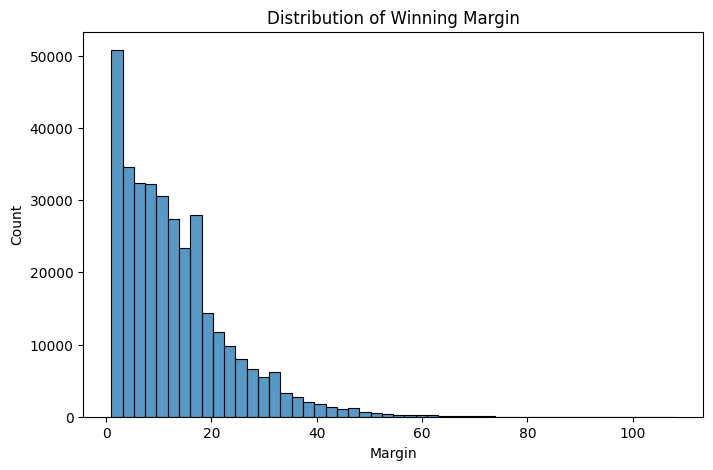

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(reg["Margin"], bins=50)
plt.title("Distribution of Winning Margin")
plt.show()

## HGBG

In [35]:
X_cols = [c for c in df.columns if c.endswith("_diff")] + ["Gender", 'Era_PaceUp',	'Era_Modern']
X_cols

['win_pct_diff',
 'avg_score_diff',
 'avg_allowed_diff',
 'avg_margin_diff',
 'SeedNum_diff',
 'Gender',
 'Era_PaceUp',
 'Era_Modern']

In [36]:
# Years to leave out as validation one at a time
val_years = [2019, 2021, 2022, 2023, 2024, 2025]

brier_scores = []

for val_year in tqdm(val_years, desc="LOSO CV Seasons"):
    # Train on all previous seasons
    train_mask = df["Season"] < val_year
    val_mask   = df["Season"] == val_year

    X_train = df.loc[train_mask, X_cols]
    y_train = df.loc[train_mask, "Target"]

    X_val   = df.loc[val_mask, X_cols]
    y_val   = df.loc[val_mask, "Target"]

    # Fit model
    model = HistGradientBoostingClassifier(
        loss="log_loss",
        # max_depth=6,
        # learning_rate=0.05,
        # max_iter=500,
        random_state=31
    )

    model.fit(X_train, y_train)

    # Predict
    pred_val = model.predict_proba(X_val)[:,1]

    # Compute Brier score
    brier = brier_score_loss(y_val, pred_val)
    brier_scores.append((val_year, brier))

    # Optional: can print per season if you want more verbose
    print(f"Season {val_year}: Brier Score = {brier:.4f}")

# Summary
avg_brier = np.mean([b for _, b in brier_scores])
print("\nAverage Brier score 2019-2025:", round(avg_brier,4))

LOSO CV Seasons:  17%|█▋        | 1/6 [00:00<00:01,  3.63it/s]

Season 2019: Brier Score = 0.1669


LOSO CV Seasons:  33%|███▎      | 2/6 [00:00<00:01,  3.89it/s]

Season 2021: Brier Score = 0.1979


LOSO CV Seasons:  50%|█████     | 3/6 [00:00<00:00,  3.85it/s]

...

Season 2023: Brier Score = 0.2170


LOSO CV Seasons:  83%|████████▎ | 5/6 [00:01<00:00,  4.00it/s]

Season 2024: Brier Score = 0.1695


LOSO CV Seasons: 100%|██████████| 6/6 [00:01<00:00,  3.96it/s]

Season 2025: Brier Score = 0.1624

Average Brier score 2019-2025: 0.1889


In [37]:
# --- Final Model Training ---
print("\nTraining final model on all available data (through 2026)...")
X_all = df[X_cols]
y_all = df["Target"]

model = HistGradientBoostingClassifier(
    loss="log_loss",
    random_state=31
)

model.fit(X_all, y_all)


Training final model on all available data (through 2026)...


HistGradientBoostingClassifier(random_state=31)

In [39]:
import pandas as pd
import numpy as np

# Load sample submission
sub = pd.read_csv("/content/SampleSubmissionStage1.csv")

# Parse IDs
sub[["Season","Team1","Team2"]] = sub["ID"].str.split("_", expand=True)
sub["Season"] = sub["Season"].astype(int)
sub["Team1"]  = sub["Team1"].astype(int)
sub["Team2"]  = sub["Team2"].astype(int)
# sub["Gender"] = 1

# Era one-hot (k-1)
sub["Era_PaceUp"]  = (sub["Season"].apply(assign_era) == "PaceUp").astype(int)
sub["Era_Modern"]  = (sub["Season"].apply(assign_era) == "Modern").astype(int)

# Merge T1/T2 stats (diff features)
t1_stats = season_stats.rename(columns={col: f"T1_{col}" for col in feature_cols})
t2_stats = season_stats.rename(columns={col: f"T2_{col}" for col in feature_cols})

sub = sub.merge(
    t1_stats,
    left_on=["Season","Team1"],
    right_on=["Season","TeamID"],
    how="left"
).drop(columns=["TeamID"])

sub = sub.merge(
    t2_stats,
    left_on=["Season","Team2"],
    right_on=["Season","TeamID"],
    how="left"
).drop(columns=["TeamID"])

# Compute diff features
for col in feature_cols:
    sub[f"{col}_diff"] = sub[f"T1_{col}"] - sub[f"T2_{col}"]

sub['Gender'] = sub.filter(like = 'Gender').mean(axis = 1).astype(int)

# Final features for prediction
X_sub = X_cols

# --- Predict using your already trained model ---
sub["Pred"] = model.predict_proba(sub[X_sub])[:,1]  # <--- reuse the CV/final model

In [45]:
sub.filter(like = 'Seed')

,Seed_x,T1_SeedNum,Seed_y,T2_SeedNum,SeedNum_diff
0,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,W13,13.0,NaN
2,NaN,NaN,X06,6.0,NaN
3,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...
519139,NaN,NaN,NaN,NaN,NaN
519140,NaN,NaN,NaN,NaN,NaN
519141,NaN,NaN,NaN,NaN,NaN
519142,NaN,NaN,NaN,NaN,NaN


In [46]:
# Post Processing
sub["Pred"] = sub["Pred"].clip(0.025, 0.975)


# MEN ONLY (Gender == 1)
mask_m = sub["Gender"] == 1

sub.loc[mask_m & (sub["T1_SeedNum"] == 16) & (sub["T2_SeedNum"] == 1), "Pred"] = 0
sub.loc[mask_m & (sub["T1_SeedNum"] == 15) & (sub["T2_SeedNum"] == 2), "Pred"] = 0
sub.loc[mask_m & (sub["T1_SeedNum"] == 14) & (sub["T2_SeedNum"] == 3), "Pred"] = 0
sub.loc[mask_m & (sub["T1_SeedNum"] == 13) & (sub["T2_SeedNum"] == 4), "Pred"] = 0

sub.loc[mask_m & (sub["T1_SeedNum"] == 1) & (sub["T2_SeedNum"] == 16), "Pred"] = 1
sub.loc[mask_m & (sub["T1_SeedNum"] == 2) & (sub["T2_SeedNum"] == 15), "Pred"] = 1
sub.loc[mask_m & (sub["T1_SeedNum"] == 3) & (sub["T2_SeedNum"] == 14), "Pred"] = 1
sub.loc[mask_m & (sub["T1_SeedNum"] == 4) & (sub["T2_SeedNum"] == 13), "Pred"] = 1


# WOMEN ONLY (Gender == 0)
mask_w = sub["Gender"] == 0

sub.loc[mask_w & (sub["T1_SeedNum"] == 16) & (sub["T2_SeedNum"] == 1), "Pred"] = 0
sub.loc[mask_w & (sub["T1_SeedNum"] == 15) & (sub["T2_SeedNum"] == 2), "Pred"] = 0
sub.loc[mask_w & (sub["T1_SeedNum"] == 14) & (sub["T2_SeedNum"] == 3), "Pred"] = 0
sub.loc[mask_w & (sub["T1_SeedNum"] == 13) & (sub["T2_SeedNum"] == 4), "Pred"] = 0

sub.loc[mask_w & (sub["T1_SeedNum"] == 1) & (sub["T2_SeedNum"] == 16), "Pred"] = 1
sub.loc[mask_w & (sub["T1_SeedNum"] == 2) & (sub["T2_SeedNum"] == 15), "Pred"] = 1
sub.loc[mask_w & (sub["T1_SeedNum"] == 3) & (sub["T2_SeedNum"] == 14), "Pred"] = 1
sub.loc[mask_w & (sub["T1_SeedNum"] == 4) & (sub["T2_SeedNum"] == 13), "Pred"] = 1

In [47]:
sub[["ID","Pred"]].to_csv('/content/drive/MyDrive/Output/sub.csv', index=False)

In [48]:
!kaggle competitions submit -c march-machine-learning-mania-2026 -f /content/drive/MyDrive/Output/sub.csv -m "v3 hgbg w post processing"

100% 16.6M/16.6M [00:00<00:00, 53.3MB/s]
Successfully submitted to March Machine Learning Mania 2026

## Save to Github

In [50]:
!git config --global user.email "abishpius@gmail.com"
!git config --global user.name "Abish Pius"

In [51]:
from google.colab import userdata
import requests

token = userdata.get('github')
repo_name = "March-Madness-2026"
username = "abishpius"
message = "Kaggle Competition March Madness 2026"
notebook_name = "Kaggle_March_Madness.ipynb"

headers = {
    "Authorization": f"token {token}",
    "Accept": "application/vnd.github+json"
}

# === CHECK IF REPO EXISTS ===
check_url = f"https://api.github.com/repos/{username}/{repo_name}"
check_resp = requests.get(check_url, headers=headers)

if check_resp.status_code == 200:
    print(f"❌ Repo '{repo_name}' already exists at: https://github.com/{username}/{repo_name}")
else:
    # === CREATE REPO ===
    create_url = "https://api.github.com/user/repos"
    payload = {
        "name": repo_name,
        "auto_init": True,
        "private": False  # change to True if you want a private repo
    }

    create_resp = requests.post(create_url, headers=headers, json=payload)

    if create_resp.status_code == 201:
        print(f"✅ Repo '{repo_name}' created successfully.")

        # === UPDATE README.md ===
        import base64

        update_url = f"https://api.github.com/repos/{username}/{repo_name}/contents/README.md"
        readme_text = ""
        encoded = base64.b64encode(readme_text.encode()).decode()
        update_payload = {
            "message": message,
            "content": encoded,
            "sha": requests.get(update_url, headers=headers).json()["sha"]
        }

        update_resp = requests.put(update_url, headers=headers, json=update_payload)

        if update_resp.status_code == 200 or update_resp.status_code == 201:
            print("✅ README.md updated with custom text.")
        else:
            print("⚠️ Failed to update README.md:", update_resp.json())

    else:
        print("❌ Repo creation failed:", create_resp.json())

❌ Repo 'March-Madness-2026' already exists at: https://github.com/abishpius/March-Madness-2026


In [ ]:
!git clone https://{token}@github.com/{username}/{repo_name}.git

# === MOVE NOTEBOOK ===
import shutil
shutil.copy(f"/content/drive/MyDrive/Colab Notebooks/{notebook_name}", f"/content/{repo_name}/{notebook_name}")

# === COMMIT TO REPO ===
%cd {repo_name}
!git add {notebook_name}
!git commit -m "HGBG Model + ne"
!git push

fatal: destination path 'March-Madness-2026' already exists and is not an empty directory.
/content/March-Madness-2026
[main 95d90b7] Primary HGBG Models
 1 file changed, 1 insertion(+)
 create mode 100644 Kaggle_March_Madness.ipynb
Enumerating objects: 4, done.
Counting objects: 100% (4/4), done.
Delta compression using up to 2 threads
Compressing objects: 100% (3/3), done.
Writing objects: 100% (3/3), 32.97 KiB | 6.59 MiB/s, done.
Total 3 (delta 0), reused 0 (delta 0), pack-reused 0
To https://github.com/abishpius/March-Madness-2026.git
   6aea08a..95d90b7  main -> main
